In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
data = pd.read_csv("insurance.csv")

In [32]:
data.head()

,age,sex,bmi,children,smoker,charges
0,19,1,27.900,0,1,16884.92400
1,18,0,33.770,1,0,1725.55230
2,28,0,33.000,3,0,4449.46200
3,33,0,22.705,0,0,21984.47061
4,32,0,28.880,0,0,3866.85520


# Data exploring 

In [33]:
data.head()

,age,sex,bmi,children,smoker,charges
0,19,1,27.900,0,1,16884.92400
1,18,0,33.770,1,0,1725.55230
2,28,0,33.000,3,0,4449.46200
3,33,0,22.705,0,0,21984.47061
4,32,0,28.880,0,0,3866.85520


<Axes: >

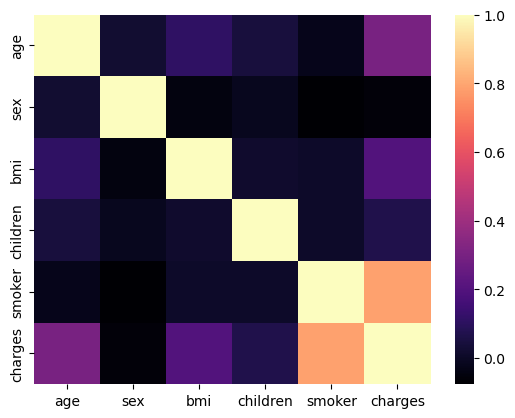

In [34]:
correlation_matrix = data.corr()

sns.heatmap(data.corr(), cmap="magma")

# Data splitting
we will use the standard 80-20 split

In [35]:
from sklearn.model_selection import train_test_split

In [36]:
X = data.drop(["charges"], axis = 1)
y = data["charges"]

In [37]:
# we have to normalise 
X = (X - X.mean(axis=0))/X.std(axis=0)
y = (y- y.mean(axis=0))/y.std(axis=0)

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state = 18)

# Model Building

In [39]:
class LinearRegression:
    def __init__(self, learning_Rate = 0.001, n_iter = 1000):
        #weights and biases
        self.bias = None
        self.weights = None
        self.lr = learning_Rate
        self.n_iter = n_iter

    def fit(self, X, y):
        m,n = X.shape #number of samples, number of features

        # assuming parameters
        self.bias = 0
        self.weights = np.zeros(n)

        # gradient descent
        for i in range(self.n_iter):
            y_ = self.bias + np.dot(X,self.weights)

            db = (1/m) * np.sum(y_ - y)
            dw = (1/m) * np.dot(X.T, (y_ - y))

            self.bias -= self.lr*db
            self.weights -= self.lr*dw

    def predict(self, x):
        ans = self.bias + np.dot(x, self.weights)
        return ans

In [40]:
X_train

,age,sex,bmi,children,smoker
1153,-0.299433,1.010141,0.844776,-0.078738,-0.507273
1100,-0.441782,1.010141,-1.897022,0.750799,1.969850
661,1.266407,1.010141,-1.095965,-0.078738,-0.507273
147,0.839360,1.010141,1.158804,-0.078738,-0.507273
534,1.764630,-0.989221,1.609758,-0.908274,-0.507273
...,...,...,...,...,...
1198,0.056440,-0.989221,-0.214555,-0.078738,-0.507273
837,1.195233,1.010141,-0.385917,-0.908274,-0.507273
1144,0.768185,-0.989221,0.268375,0.750799,-0.507273
275,0.554662,1.010141,-0.666329,0.750799,-0.507273


In [41]:
y_train

1153   -0.630880
1100    0.289503
661     0.736747
147    -0.280166
534     0.046300
          ...   
1198   -0.567862
837    -0.133171
1144   -0.300580
275    -0.293524
1322   -0.023871
Name: charges, Length: 1070, dtype: float64

In [42]:
model = LinearRegression()
model.fit(X_train.to_numpy(),y_train.to_numpy())

# Evalutaing out model

In [43]:
y_predict = model.predict(X_test.to_numpy())

In [44]:
y_test

381     2.397460
38      2.188590
197    -0.392534
14      2.175170
94      2.809298
          ...   
977    -0.856111
1108   -0.856014
8      -0.566805
808    -1.002387
816    -0.861078
Name: charges, Length: 268, dtype: float64

In [45]:
y_predict

array([ 1.16959954,  1.04124924, -0.20837316,  0.9997782 ,  1.307757  ,
       -0.48252709,  0.94893828,  0.04033149,  1.12357382,  0.9462052 ,
       -0.68700249,  0.89551567,  1.1677892 , -0.52094338,  0.04855687,
       -0.10933488, -0.04995843,  0.50141598, -0.2118585 ,  0.79062166,
        1.14444563, -0.24571768, -0.49129622, -0.44239641, -0.66647444,
       -0.54983317,  0.62077946, -0.45225701, -0.46265984,  0.58877429,
        0.89042826, -0.69670275, -0.43035551, -0.57044405,  0.67715245,
       -0.60747309,  0.13691174, -0.07951653,  0.89023197, -0.53798273,
       -0.45768429,  1.11251461, -0.43459908,  1.06842603, -0.25664018,
       -0.51018592,  1.28910699,  1.02815646, -0.23568374, -0.71254888,
       -0.14692325,  0.83574051, -0.53597183, -0.31163967, -0.46257041,
       -0.3428686 , -0.14154823,  0.02058414, -0.40047431, -0.44073146,
        0.03172909, -0.4615019 , -0.36771606, -0.25081091, -0.24978383,
       -0.16845318, -0.26586362, -0.57704267, -0.08257813, -0.23

In [46]:
from sklearn.metrics import r2_score

r2_score(y_test, y_predict)

0.6624012938411348

In [ ]:
``